<a href="https://colab.research.google.com/github/vhemashre597-crypto/ML-PROJECTS/blob/main/Anemia_Prediction_using_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

df = pd.read_csv('anemia.csv')
df.head()

,Gender,Hemoglobin,MCH,MCHC,MCV,Result
0,1,14.9,22.7,29.1,83.7,0
1,0,15.9,25.4,28.3,72.0,0
2,0,9.0,21.5,29.6,71.2,1
3,0,14.9,16.0,31.4,87.5,0
4,1,14.7,22.0,28.2,99.5,0


In [ ]:
print(df.shape)
print(df.info())
print(df.isnull().sum())
print(df['Result'].value_counts())


(1421, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1421 entries, 0 to 1420
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Gender      1421 non-null   int64  
 1   Hemoglobin  1421 non-null   float64
 2   MCH         1421 non-null   float64
 3   MCHC        1421 non-null   float64
 4   MCV         1421 non-null   float64
 5   Result      1421 non-null   int64  
dtypes: float64(4), int64(2)
memory usage: 66.7 KB
None
Gender        0
Hemoglobin    0
MCH           0
MCHC          0
MCV           0
Result        0
dtype: int64
Result
0    801
1    620
Name: count, dtype: int64


In [ ]:
X = df.drop('Result', axis=1)
y = df['Result']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

Accuracy: 1.0

Confusion Matrix:
 [[157   0]
 [  0 128]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       157
           1       1.00      1.00      1.00       128

    accuracy                           1.00       285
   macro avg       1.00      1.00      1.00       285
weighted avg       1.00      1.00      1.00       285



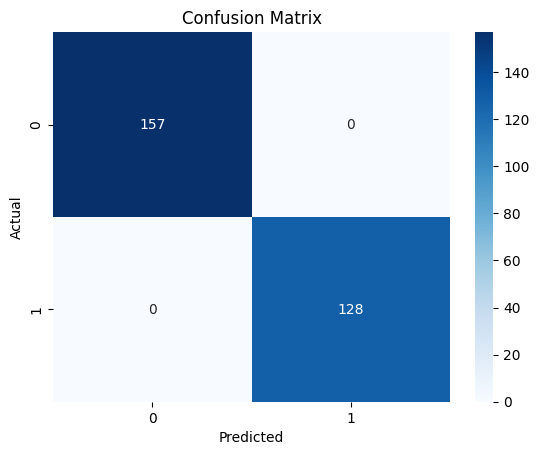

In [ ]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
X_reg = df.drop(['Hemoglobin', 'Result'], axis=1)
y_reg = df['Hemoglobin']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

scaler_r = StandardScaler()
X_train_r = scaler_r.fit_transform(X_train_r)
X_test_r = scaler_r.transform(X_test_r)

In [ ]:
reg_model = RandomForestRegressor(n_estimators=100, random_state=42)
reg_model.fit(X_train_r, y_train_r)
y_pred_r = reg_model.predict(X_test_r)

In [ ]:
print("MAE:", mean_absolute_error(y_test_r, y_pred_r))
print("RMSE:", np.sqrt(mean_squared_error(y_test_r, y_pred_r)))
print("R² Score:", r2_score(y_test_r, y_pred_r))

MAE: 0.6226770843776116
RMSE: 1.046420316766636
R² Score: 0.7203054384423496


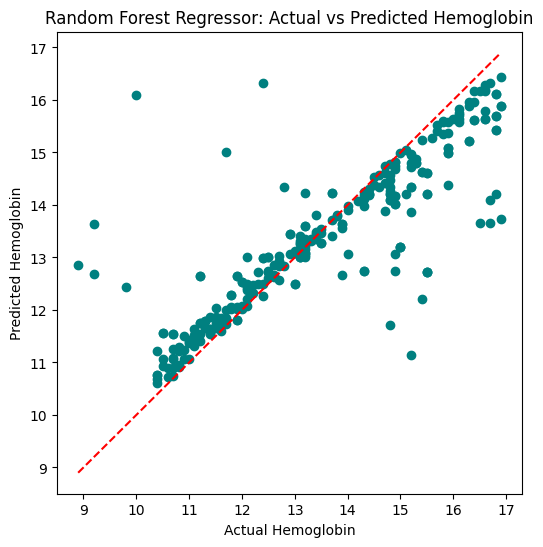

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_test_r, y_pred_r, color='teal')
plt.plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], 'r--')
plt.xlabel("Actual Hemoglobin")
plt.ylabel("Predicted Hemoglobin")
plt.title("Random Forest Regressor: Actual vs Predicted Hemoglobin")
plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42)
}

for name, m in models.items():
    m.fit(X_train_r, y_train_r)
    pred = m.predict(X_test_r)
    print(f"{name} -> R²: {r2_score(y_test_r, pred):.3f}, MAE: {mean_absolute_error(y_test_r, pred):.3f}")

Linear Regression -> R²: -0.016, MAE: 1.731
Decision Tree -> R²: 0.717, MAE: 0.323
Random Forest -> R²: 0.720, MAE: 0.623


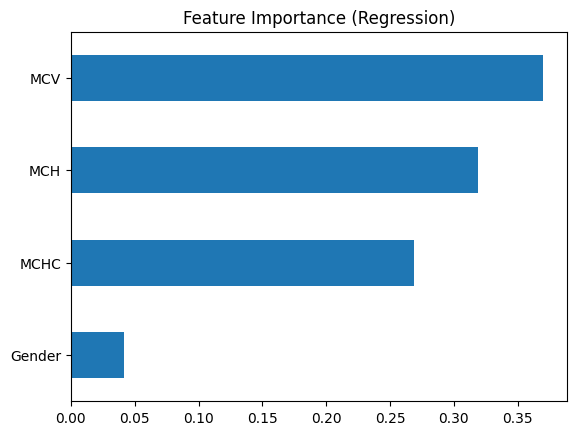

In [ ]:
importances = pd.Series(reg_model.feature_importances_, index=X_reg.columns)
importances.sort_values().plot(kind='barh', title='Feature Importance (Regression)')
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(reg_model, X_reg, y_reg, cv=5, scoring='r2')
print("Cross-val R² scores:", scores)
print("Average R²:", scores.mean())

Cross-val R² scores: [0.55820118 0.38457053 0.69497786 0.91101848 0.92572466]
Average R²: 0.6948985425633181


In [ ]:
from sklearn.model_selection import GridSearchCV

params = {'n_estimators': [50, 100, 200], 'max_depth': [None, 5, 10]}
grid = GridSearchCV(RandomForestRegressor(random_state=42), params, cv=3, scoring='r2')
grid.fit(X_train_r, y_train_r)
print("Best params:", grid.best_params_)
print("Best R²:", grid.best_score_)

Best params: {'max_depth': None, 'n_estimators': 200}
Best R²: 0.38905651531043484


In [ ]:
best_model = RandomForestRegressor(n_estimators=200, max_depth=None, random_state=42)
best_model.fit(X_train_r, y_train_r)
y_pred_best = best_model.predict(X_test_r)

print("Tuned R²:", r2_score(y_test_r, y_pred_best))
print("Tuned MAE:", mean_absolute_error(y_test_r, y_pred_best))

Tuned R²: 0.7183925844242594
Tuned MAE: 0.6314410338345832
